# General Radial-Spectrum Line Scattering

This notebook uses a sampled isotropic radial k spectrum, such as `gaussian_radial`, and computes the covariance numerically as an average of `sinc(k r)`. It does not use the monochromatic `sin(k0 r)/(k0 r)` covariance except as an optional reference.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rw_line_scattering as ris

plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Radial Spectrum

In [2]:
# k0_nominal = 1.0
# k_distribution = "max_entropy_radial"
# num_modes_k = 2**13
# k_distribution_params = {
#     "r_sigma_k": 0.12,
#     "skewness": 0.2,
#     "support_sigma": 4.0,
# }
# r_sigma_k = k_distribution_params["r_sigma_k"]
# random_seed = 12345

k0_nominal = 1.0
k_distribution = "gaussian_radial"
num_modes_k = 2**13
k_distribution_params = {
    "r_sigma_k": 0.4,
}
r_sigma_k = k_distribution_params["r_sigma_k"]
random_seed = 12345

# Options: "qmc", "random", or "quadrature".
k_sampling = "qmc"

if k_sampling == "quadrature":
    k_radii, k_weights = ris.make_radial_k_quadrature(
        num_modes_k,
        k_distribution,
        k0=k0_nominal,
        sigma_k=r_sigma_k*k0_nominal,
        distribution_params=k_distribution_params,
    )
else:
    k_rng = np.random.default_rng(random_seed)
    k_sets = ris.make_field_k_sets(
        num_modes_k,
        k_distribution,
        k_rng,
        k0=k0_nominal,
        r_sigma_k=r_sigma_k,
        distribution_params=k_distribution_params,
        shared_k_vectors=True,
        use_qmc_k=(k_sampling == "qmc"),
        qmc_seed=random_seed,
    )
    k_radii = ris.k_radii_from_vectors(k_sets.psi1)
    k_weights = None

a = ris.gradient_variance_from_k_radii(k_radii, k_weights=k_weights)
rho0 = ris.rho0_from_k_radii(k_radii, k_weights=k_weights)
k_eff = np.sqrt(3*a)

k_mean = np.mean(k_radii) if k_weights is None else np.dot(k_weights, k_radii)
k_std = np.std(k_radii) if k_weights is None else np.sqrt(np.dot(k_weights, (k_radii-k_mean)**2))
k_skewness = (
    np.mean((k_radii-k_mean)**3)
    if k_weights is None
    else np.dot(k_weights, (k_radii-k_mean)**3)
) / k_std**3

print(f"distribution = {k_distribution}")
print(f"k sampling = {k_sampling}")
print(f"nominal k0 = {k0_nominal:.12g}")
print(f"effective k_eff = sqrt(<k^2>) = {k_eff:.12g}")
print(f"mean |k| = {k_mean:.12g}")
print(f"std |k| = {k_std:.12g}")
print(f"skewness |k| = {k_skewness:.12g}")
print(f"a = <k^2>/3 = {a:.12g}")
print(f"rho0 = a/pi = {rho0:.12g}")
print(f"rho0^2 = {rho0**2:.12g}")


distribution = gaussian_radial
k sampling = qmc
nominal k0 = 1
effective k_eff = sqrt(<k^2>) = 1.08035234902
mean |k| = 1.0070750147
std |k| = 0.391102432608
skewness |k| = 0.104163307603
a = <k^2>/3 = 0.389053732676
rho0 = a/pi = 0.123839649367
rho0^2 = 0.0153362587554


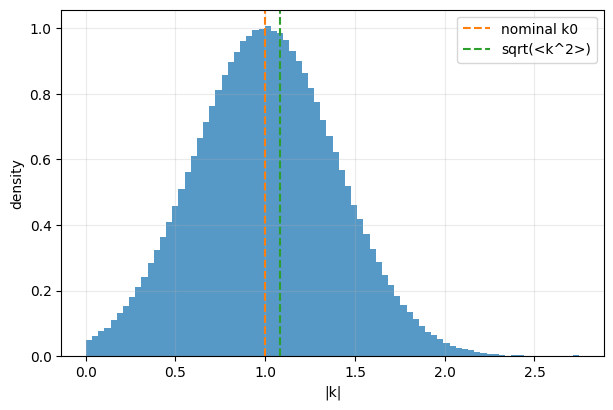

In [3]:
fig, ax = plt.subplots()
ax.hist(k_radii, bins=80, density=True, weights=k_weights, alpha=0.75)
ax.axvline(k0_nominal, color="tab:orange", linestyle="--", label="nominal k0")
ax.axvline(k_eff, color="tab:green", linestyle="--", label="sqrt(<k^2>)")
ax.set_xlabel("|k|")
ax.set_ylabel("density")
ax.legend()
plt.show()


## Grids

In [4]:
# r_min = 1e-3 / k_eff
# r_max = 5e2 / k_eff
# Nr = 10000
# r_grid = np.linspace(r_min, r_max, Nr)
# # r_grid = np.logspace(np.log10(r_min), np.log10(r_max), Nr)

r_min = 1e-3 / k_eff
r_max = 250 / k_eff
r_split = 5.0 / k_eff

Nr = 3000
Nr_small = 600

r_grid = ris.make_r_grid(
    r_min,
    r_max,
    Nr,
    mode="mixed",
    r_split=r_split,
    n_small=Nr_small,
)

Q_min = 0.1 * k_eff
Q_max = 20 * k_eff
NQ = 256
Q_grid = np.logspace(np.log10(Q_min), np.log10(Q_max), NQ)

tail_start = 0.8 * r_max

print(f"r range: {r_grid[0]:.6g} to {r_grid[-1]:.6g}; Nr={len(r_grid)}; dr={r_grid[1]-r_grid[0]:.6g}")
print(f"Q/k_eff range: {Q_grid[0]/k_eff:.6g} to {Q_grid[-1]/k_eff:.6g}; NQ={len(Q_grid)}")
print(f"tail window starts at r = {tail_start:.6g}")

r range: 0.000925624 to 231.406; Nr=3001; dr=0.00771199
Q/k_eff range: 0.1 to 20; NQ=256
tail window starts at r = 185.125


## Numerical Covariance

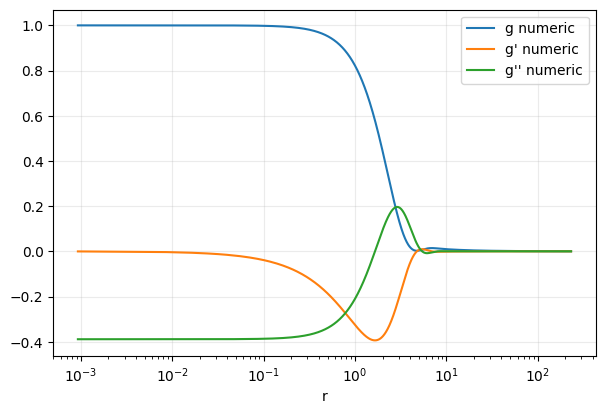

In [5]:
g_num, gp_num, gpp_num = ris.radial_covariance_numeric(r_grid, k_radii, k_weights=k_weights)

fig, ax = plt.subplots()
ax.plot(r_grid, g_num, label="g numeric")
ax.plot(r_grid, gp_num, label="g' numeric")
ax.plot(r_grid, gpp_num, label="g'' numeric")
ax.set_xlabel("r")
ax.set_xscale("log")
ax.legend()
plt.show()


## Line-Density Correlation

In [6]:
N_samp = 2**15
use_qmc = True
jacobian_method = "direct_12d"  # "direct_12d" or "conditional_6d_2d"
N_samp_U = N_samp
N_samp_st = 2**8
U_sampling = "qmc" if use_qmc else "random"
st_sampling = "quadrature"  # "quadrature" or "qmc"
st_transform = "rational"

print(f"jacobian_method = {jacobian_method}; N_samp_U = {N_samp_U}; N_samp_st = {N_samp_st}")

M_J, C_L = ris.compute_CL_general(
    r_grid,
    k_radii,
    N_samp,
    k_weights=k_weights,
    use_qmc=use_qmc,
    random_seed=random_seed,
    progress=True,
    jacobian_method=jacobian_method,
    N_samp_U=N_samp_U,
    N_samp_st=N_samp_st,
    U_sampling=U_sampling,
    st_sampling=st_sampling,
    st_transform=st_transform,
)
C_L_coherent = ris.coherent_CL_general(C_L, k_radii, k_weights=k_weights)

print(f"empirical M_J(r_min={r_grid[0]:.6g}) = {M_J[0]:.12g}")
print(f"empirical M_J(r_max={r_grid[-1]:.6g}) = {M_J[-1]:.12g}")


jacobian_method = direct_12d; N_samp_U = 32768; N_samp_st = 256
M_J direct_12d: 150/3001 r values (1.6s)
M_J direct_12d: 300/3001 r values (3.3s)
M_J direct_12d: 450/3001 r values (4.8s)
M_J direct_12d: 600/3001 r values (6.3s)
M_J direct_12d: 750/3001 r values (7.9s)
M_J direct_12d: 900/3001 r values (9.5s)
M_J direct_12d: 1050/3001 r values (11.1s)
M_J direct_12d: 1200/3001 r values (12.6s)
M_J direct_12d: 1350/3001 r values (14.3s)
M_J direct_12d: 1500/3001 r values (15.9s)
M_J direct_12d: 1650/3001 r values (17.5s)
M_J direct_12d: 1800/3001 r values (19.1s)
M_J direct_12d: 1950/3001 r values (20.7s)
M_J direct_12d: 2100/3001 r values (22.2s)
M_J direct_12d: 2250/3001 r values (23.7s)
M_J direct_12d: 2400/3001 r values (25.2s)
M_J direct_12d: 2550/3001 r values (26.7s)
M_J direct_12d: 2700/3001 r values (28.4s)
M_J direct_12d: 2850/3001 r values (29.9s)
M_J direct_12d: 3000/3001 r values (31.3s)
M_J direct_12d: 3001/3001 r values (31.3s)
empirical M_J(r_min=0.000925624) = 0.30307711

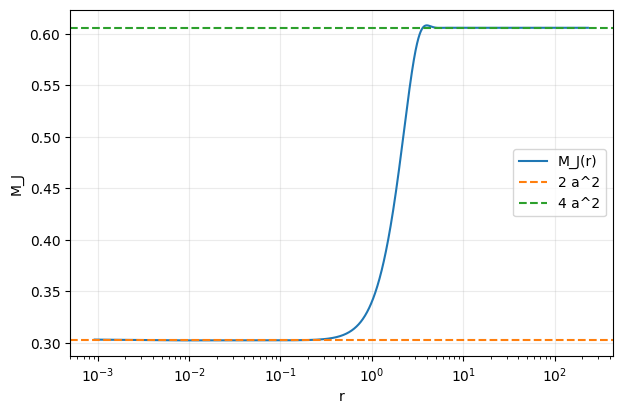

In [7]:
fig, ax = plt.subplots()
ax.plot(r_grid, M_J, label="M_J(r)")
ax.axhline(2*a*a, color="tab:orange", linestyle="--", label="2 a^2")
ax.axhline(4*a*a, color="tab:green", linestyle="--", label="4 a^2")
ax.set_xlabel("r")
ax.set_ylabel("M_J")
ax.set_xscale("log")
ax.legend()
plt.show()

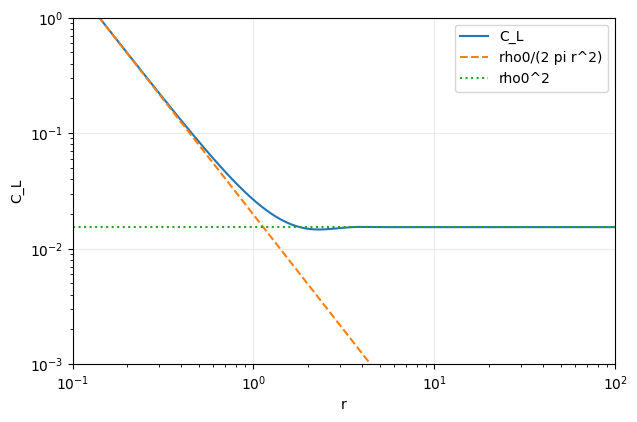

In [8]:
fig, ax = plt.subplots()
ax.loglog(r_grid, C_L, label="C_L")
ax.loglog(r_grid, rho0/(2*np.pi*r_grid**2), "--", label="rho0/(2 pi r^2)")
ax.axhline(rho0**2, color="tab:green", linestyle=":", label="rho0^2")
ax.set_xlabel("r")
ax.set_ylabel("C_L")
ax.set_xlim(1e-1, 1e2)
ax.set_ylim(1e-3, 1e0)
ax.legend()
plt.show()

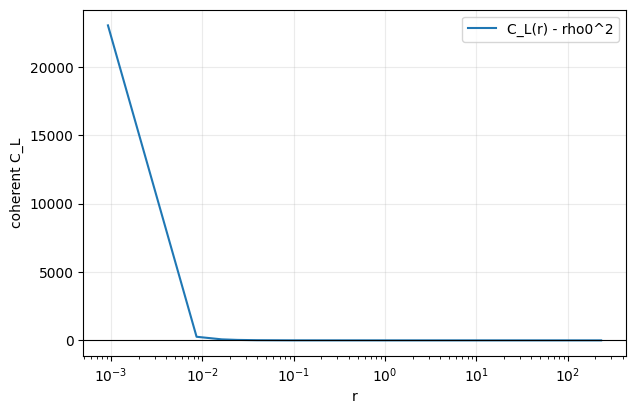

In [9]:
fig, ax = plt.subplots()
ax.semilogx(r_grid, C_L_coherent, label="C_L(r) - rho0^2")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("r")
ax.set_ylabel("coherent C_L")
ax.legend()
plt.show()

## Scattering Transform

In [10]:
use_lowq_stitch = True
lowq_fit_min_over_k_eff = 0.35
lowq_fit_max_over_k_eff = 0.80
lowq_replace_max_over_k_eff = 0.60

diag = ris.compute_coherent_transform_diagnostics(
    r_grid,
    C_L,
    Q_grid,
    rho0,
    r_taper_start=tail_start,
    use_asymptotic=use_lowq_stitch,
    lowq_fit_bounds=(lowq_fit_min_over_k_eff * k_eff, lowq_fit_max_over_k_eff * k_eff),
    lowq_replace_max=lowq_replace_max_over_k_eff * k_eff,
)

W_tail = diag["w_tail"]
C_L_coherent = diag["CL_coherent"]
C_L_transform_raw = diag["CL_transform_raw"]
C_L_transform = diag["CL_transform"]

I_Q_raw = diag["I_coherent_raw"]
I_Q_original = diag["I_coherent_windowed_original"]
I_Q_stitched = diag["I_coherent_windowed"]
I_Q_lowQ_asymptotic = diag["I_lowQ_asymptotic"]
lowQ_fit_mask = diag["lowQ_fit_mask"]
lowQ_replaced_mask = diag["lowQ_replaced_mask"]
I_Q = I_Q_stitched
I_Q_full_direct = diag["I_full_windowed"]
I_plateau_windowed = diag["I_plateau_windowed"]

high_q = (Q_grid/k_eff >= 5.0) & (Q_grid/k_eff <= 30.0)
plateau_median = np.median(Q_grid[high_q] * I_Q_stitched[high_q])
print(f"tail window starts at r = {tail_start:.6g}")
print(f"CL[-1] = {C_L[-1]:.12g}")
print(f"CL[-1] - rho0^2 = {C_L[-1] - rho0**2:.12g}")
print(f"median Q*I(Q), Q/k_eff in [5, 30] = {plateau_median:.12g}")
print(f"expected local-line plateau pi*rho0 = {np.pi*rho0:.12g}")
print(f"low-Q stitch = {use_lowq_stitch}")
print(f"fit Q/k_eff = {diag['lowQ_fit_min']/k_eff:.6g} to {diag['lowQ_fit_max']/k_eff:.6g}")
print(f"replace through Q/k_eff = {diag['lowQ_replace_max']/k_eff:.6g}")
print(f"fit relative RMSE = {diag['lowQ_relative_rmse']:.6g}")


tail window starts at r = 185.125
CL[-1] = 0.0153480161845
CL[-1] - rho0^2 = 1.17574290149e-05
median Q*I(Q), Q/k_eff in [5, 30] = 0.38599976794
expected local-line plateau pi*rho0 = 0.389053732676
low-Q stitch = True
fit Q/k_eff = 0.35 to 0.8
replace through Q/k_eff = 0.6
fit relative RMSE = 0.00694572


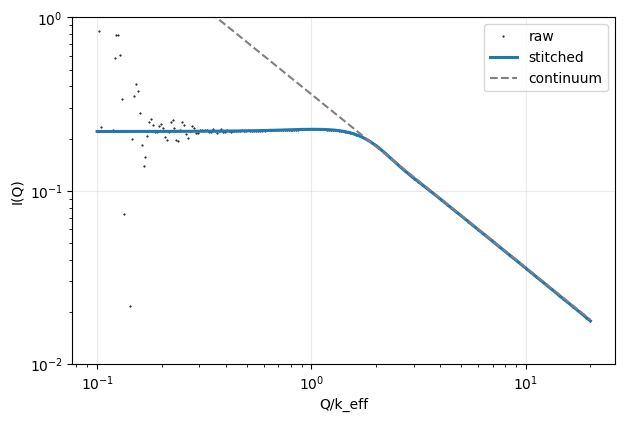

In [18]:
fig, ax = plt.subplots()
ax.loglog(Q_grid/k_eff, I_Q_original, "k.", ms=1, label="raw")
ax.loglog(Q_grid/k_eff, I_Q_stitched, "-", linewidth=2.2, label="stitched")
# ax.loglog(Q_grid/k_eff, I_Q_full_direct, alpha=0.35, label="full C_L windowed")
ax.loglog(Q_grid/k_eff, np.pi*rho0/Q_grid, "--", color="gray", label="continuum")
ax.set_xlabel("Q/k_eff")
ax.set_ylabel("I(Q)")
ax.set_ylim(1e-2, 1)
ax.legend()
plt.show()

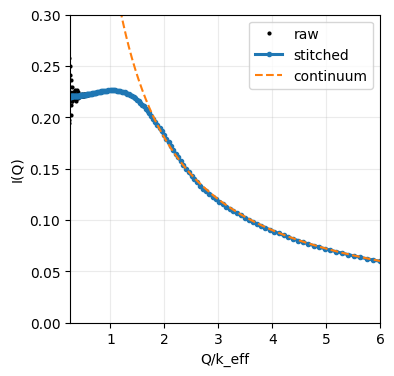

In [12]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(Q_grid/k_eff, I_Q_original, "k.", ms=4, label="raw")
ax.plot(Q_grid/k_eff, I_Q_stitched, ".-", linewidth=2.2, label="stitched")
# ax.loglog(Q_grid/k_eff, I_Q_full_direct, alpha=0.35, label="full C_L windowed")
ax.plot(Q_grid/k_eff, np.pi*rho0/Q_grid, "--", label="continuum")
ax.set_xlabel("Q/k_eff")
ax.set_ylabel("I(Q)")
ax.set_ylim(0, 0.3)
ax.set_xlim(0.25,6)
ax.legend()
plt.show()

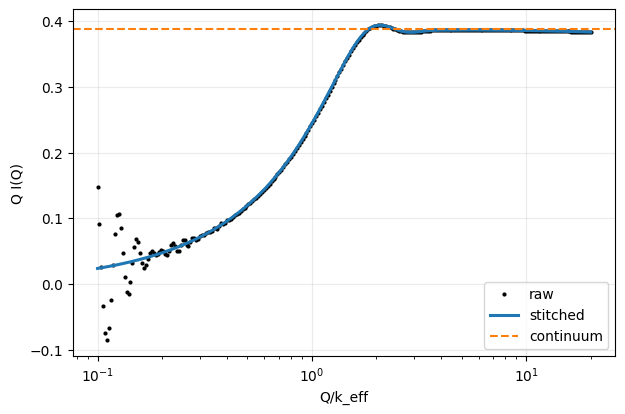

In [13]:
fig, ax = plt.subplots()
ax.semilogx(Q_grid/k_eff, Q_grid * I_Q_original, "k.", ms=4, label="raw")
ax.semilogx(Q_grid/k_eff, Q_grid * I_Q_stitched, linewidth=2.2, label="stitched")
ax.axhline(np.pi*rho0, color="tab:orange", linestyle="--", label="continuum")
ax.set_xlabel("Q/k_eff")
ax.set_ylabel("Q I(Q)")
ax.legend()
plt.show()

## Save Data

In [14]:
output_dir = Path("rw_line_general_output")
output_dir.mkdir(exist_ok=True)

np.savez(
    output_dir / "general_data.npz",
    r_grid=r_grid,
    Q_grid=Q_grid,
    k_radii=k_radii,
    k_weights=k_weights,
    M_J=M_J,
    C_L=C_L,
    C_L_coherent=C_L_coherent,
    C_L_transform=C_L_transform,
    C_L_transform_raw=C_L_transform_raw,
    W_tail=W_tail,
    I_Q=I_Q,
    I_Q_original=I_Q_original,
    I_Q_stitched=I_Q_stitched,
    I_Q_lowQ_asymptotic=I_Q_lowQ_asymptotic,
    I_Q_raw=I_Q_raw,
    I_Q_full_direct=I_Q_full_direct,
    I_plateau_windowed=I_plateau_windowed,
    lowQ_fit_mask=lowQ_fit_mask,
    lowQ_replaced_mask=lowQ_replaced_mask,
    lowQ_I0=diag["lowQ_I0"],
    lowQ_I2=diag["lowQ_I2"],
    lowQ_fit_min=diag["lowQ_fit_min"],
    lowQ_fit_max=diag["lowQ_fit_max"],
    lowQ_replace_max=diag["lowQ_replace_max"],
    lowQ_relative_rmse=diag["lowQ_relative_rmse"],
    use_lowq_stitch=use_lowq_stitch,
    k0_nominal=k0_nominal,
    k_eff=k_eff,
    a=a,
    rho0=rho0,
    k_distribution=k_distribution,
    k_sampling=k_sampling,
    r_sigma_k=r_sigma_k,
    k_skewness=k_skewness,
    N_samp=N_samp,
    jacobian_method=jacobian_method,
    N_samp_U=N_samp_U,
    N_samp_st=N_samp_st,
    U_sampling=U_sampling,
    st_sampling=st_sampling,
    st_transform=st_transform,
    random_seed=random_seed,
)
print(f"saved data to {output_dir.resolve()}")


saved data to C:\Users\ccu\Documents\codex_projects\project_randomcxl\smpl\rw_line_general_output
